## Workshop(IBM Bangalore<> - TCS )- Utility scale quantum computing application notebooks by Debasmita Bhoumik and Aaryav Mishra

## Diagonalization Algorithms -  KQD, SQD, SKQD, SQDRIFT

#  Krylov quantum diagonalization of lattice Hamiltonians

## A Chemistry Perspective (Even if You're Not a Chemist)

**Why are we computing ground state energies?**

Imagine a molecule — say, two nitrogen atoms (N₂). You want to know:
- How stable is this configuration?
- How much energy would it take to excite an electron?
- What transition wavelengths appear in the absorption spectrum?

All these questions boil down to: **What is the ground state energy?**

**Classically:** You'd solve Schrödinger equation → exponentially hard for >20 electrons  
**Quantum:** Let quantum computer evolve the state → extract energy

KQD is perfect for this *if* the interactions are nearest-neighbor (lattice). For real molecules (all-to-all), we'll see SQD is better.

---

### Analogy: Mountain Climbing

- **Full diagonalization:** Map every point on the mountain
- **Krylov subspace:** Follow one trail uphill (that's usually where the best path is)
- **Time-evolution:** Walk along this trail naturally, stopping at intervals
- **KQD:** Use these measured points to find where the valley (ground state) likely is

**Why this works:** Ground states concentrate in the Krylov subspace for most systems.



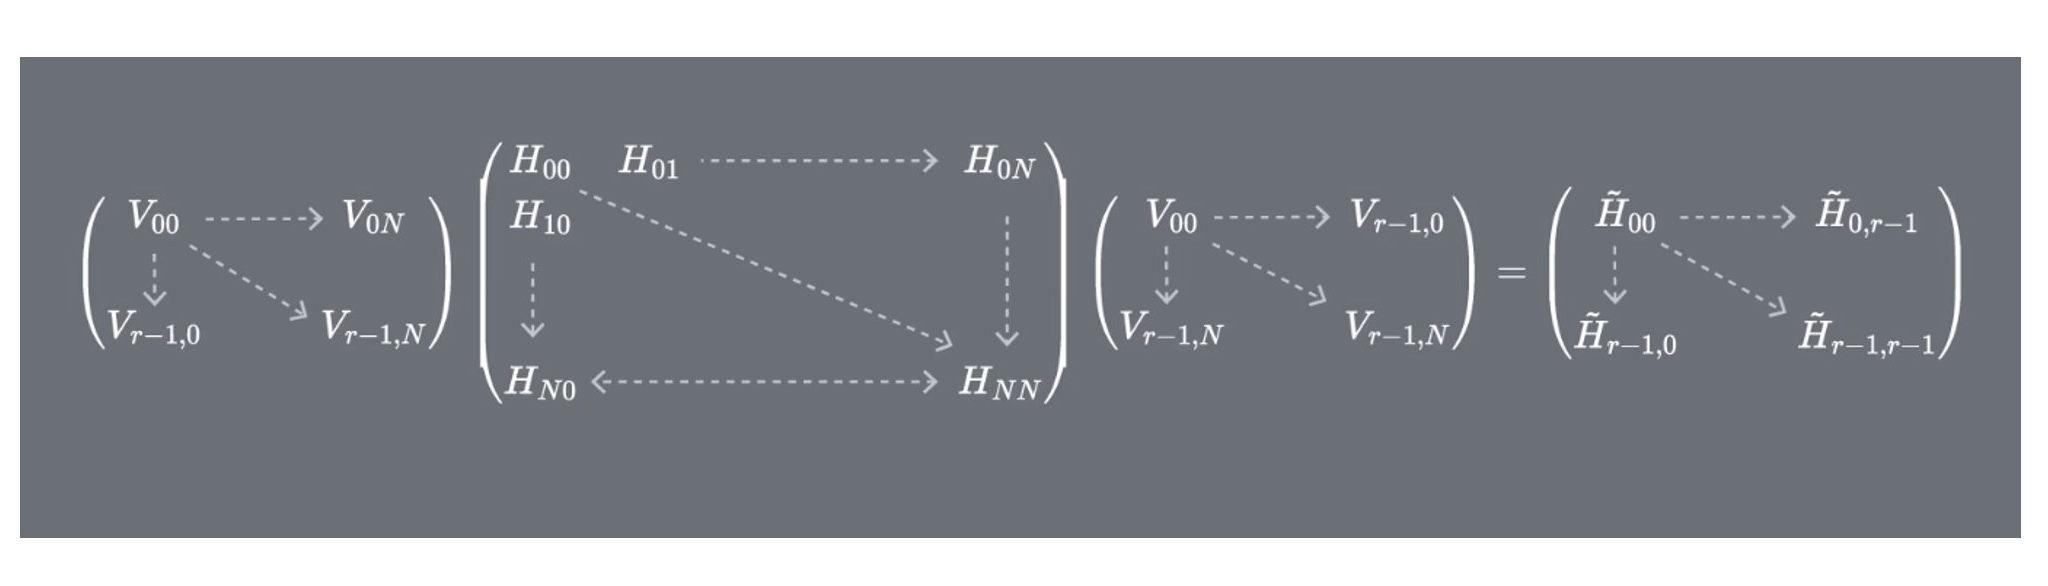

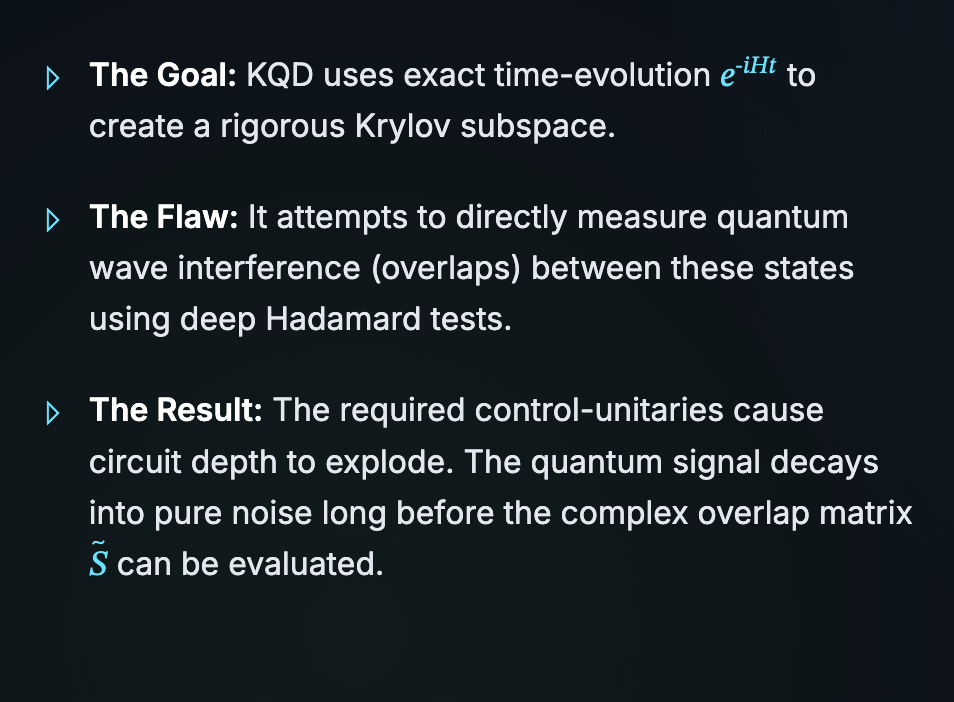

###  What KQD does better than SQD 

1. **Rigorous Convergence Guarantee**
   - Error decreases **exponentially** with subspace dimension
   - Mathematical proof, not empirical luck
   - Guaranteed accuracy growth: E₀ → E₀/2 → E₀/4 → E₀/8...

2. **Multiple Eigenvalues for Free**
   - Get ground state AND excited states in ONE run
   - No extra quantum measurements needed
   - Solve generalized eigenvalue problem once, get r eigenvalues

### VISIT https://quantum.cloud.ibm.com/docs/en/tutorials/krylov-quantum-diagonalization

##  Homework 

Now you know to compute ground state energy for a 30-qubit Heisenberg lattice.

**But you can also try:**
- Increase `krylov_dim` from 5 to 10 → Watch error shrink exponentially ✅ (KQD's promise!)
- Extract `eigenvalues[:5]` → Get ground + 4 excited states ✅ (Only KQD does this easily)


## Why We Also Need SQD

**Chemistry problem:** All-to-all electron interactions require deep time-evolution circuits. KQD would need 10,000+ gates on a real molecule.

# SQD says "I'll abandon the mathematical guarantee, but I'll run on real hardware.

Instead of deriving the basis from time-evolution (like KQD), SQD **designs** the basis using a **variational ansatz circuit**.

**The ansatz:** A human-designed quantum circuit that
- Naturally produces shallow circuits
- Captures chemistry correlations (electrons avoiding each other)
- Respects hardware topology (no expensive SWAP gates)
- Is initialized from classical CCSD (good starting point)

### What Makes SQD Different: Sampling

**KQD:** Measure quantum overlaps via Hadamard tests → build S and H̃ matrices → diagonalize classically

**SQD:** Sample bitstrings from quantum circuit → collect bitstrings → post-process classically → diagonalize in post-processing

**Key difference:** Sampling + **Configuration Recovery**
- Real QPU gives noisy bitstrings
- Many violate symmetries (wrong particle count)
- SQD *recovers* signal from these broken bitstrings
- Probabilistic flipping + iterative refinement

**Why this works:** Chemistry Hamiltonians conserve particle number & spin. We can use this constraint to recover signal!

### Example: N₂ Molecule

**The molecule:**
- 2 nitrogen atoms
- 10 valence electrons  
- 8 active orbitals (after frozen-core approximation)
- → 16 qubits total

**Full Hilbert space:** 2^16 = 65,536 states  
**Ground state:** Concentrated in ~10-100 configurations (sparse!)

**Why SQD works here:**
- Sample from LUCJ circuit → get configurations
- Most samples are in the ground-state region
- Diagonalize in this small subspace
- Result: accurate ground state energy


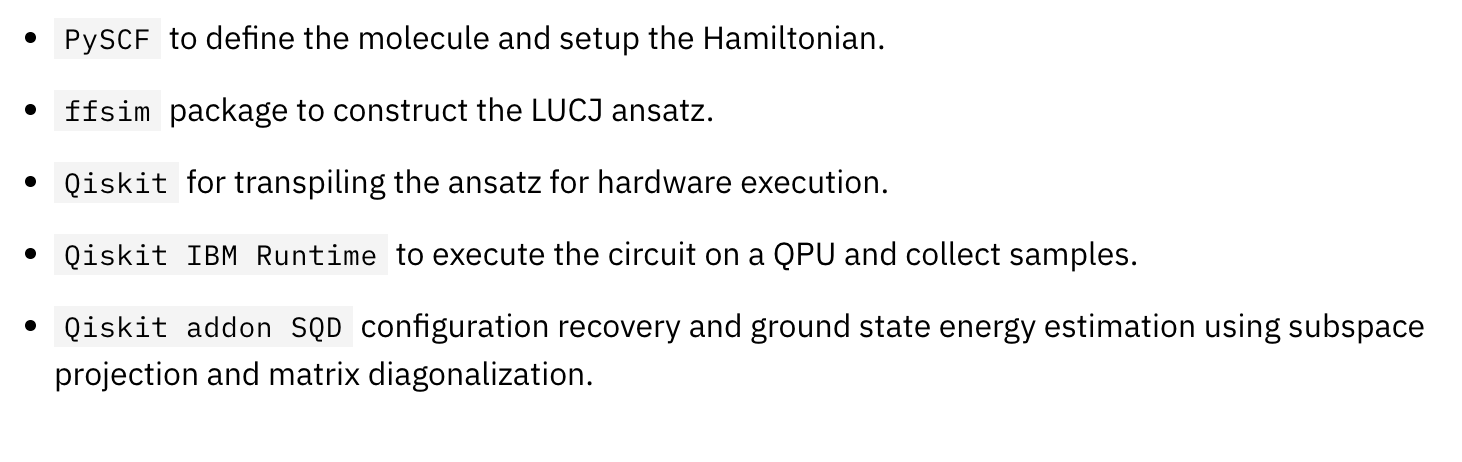

## The LUCJ Ansatz: Hardware-Friendly Chemistry

**LUCJ = Local Unitary Cluster Jastrow**
 quantum circuit designed for chemistry that respects hardware constraints.

### Why This Ansatz?

**Physical motivation:**
- Captures electron correlations (nearby electrons interact strongly)
- Antisymmetric under particle exchange (Fermi statistics)
- Initialized from CCSD (proven classical method)

**Hardware motivation:**
- Shallow circuit (no exponential depth)
- Respects  heavy-hex qubit topology
- Uses native 2-qubit gates (XX, YY, ZZ rotations)
- Avoids costly SWAP gates through clever layout

### How It Works (Conceptually)

```
Start: Hartree-Fock state (mean-field guess)
  ↓
Add correlations: Apply cluster operators
  (let nearby electrons correlate)
  ↓
Add long-range: Apply Jastrow factors
  (antisymmetrize for fermions)
  ↓
Result: Shallow circuit, rich ground state
```

### The Layout Trick (Why It's Shallow)

Normal qubit mapping: Electrons anywhere → Deep circuits

LUCJ's zig-zag layout:
```
Spin-up electrons:    ⚫---⚫---⚫---⚫  (line topology)
                       |   |   |   |    (connections)
Spin-down electrons:  ⚪---⚪---⚪---⚪  (line topology)
```

This natural ordering minimizes routing → shallow circuits!

---


## Configuration Recovery: The SQD Innovation

KQD doesn't have this problem (Hadamard tests are perfect). But SQD's sampling approach faces noise on real hardware.

**The problem:** Noisy QPU produces invalid bitstrings

- Valid bitstring: Has right number of electrons in spin-up & spin-down
- Invalid bitstring: Noise flipped a bit, violates particle count
- Naïve approach: Discard invalid bitstrings (waste 50% of samples!)
- SQD approach: **Recover** the signal (use all samples!)

### How Configuration Recovery Works

**Iterative refinement loop:**

1. **Identify invalid configs**
   - Count electrons in each spin sector
   - Spot: Too many electrons here, too few there

2. **Estimate occupancies**
   - From valid bitstrings: Which orbitals are typically occupied?
   - Build a probability model

3. **Recover invalid configs**
   - For invalid bitstring: Probabilistically flip bits
   - Target: Match the estimated occupancy pattern
   - Result: Convert invalid → valid (with some correlation preserved)

4. **Iterate**
   - Repeat steps 1-3 several times
   - Converges when occupancy pattern stabilizes

### Why This Works

**Chemistry insight:** Even noisy bitstrings contain signal!
- Noise flipped ~1% of bits
- Ground state pattern still recognizable
- Probabilistic recovery extracts that pattern

**Example:**
```
True ground state:   |00111100⟩ (electrons in orbitals 2,3,4,5)
Noisy measurement:   |00110100⟩ (one bit flipped by noise)
Config recovery:     |00111100⟩ (recovered!)
```

**SQD's promise:** "We extract 90%+ of valid samples from noise"

---

**Compare to KQD:**
- KQD: Uses Hadamard tests (mathematically perfect, but expensive)
- SQD: Uses sampling + recovery (approximate, but practical)

# Sample-based quantum diagonalization of a chemistry Hamiltonian




## Background

In this tutorial, we show how to post-process noisy quantum samples to approximate the ground state of the nitrogen molecule $\text{N}_2$ at equilibrium bond length, by using the [SQD Qiskit addon](https://github.com/Qiskit/qiskit-addon-sqd) to implement the [sample-based quantum diagonalization (SQD) algorithm](https://arxiv.org/abs/2405.05068). More details on the software can be found in the corresponding [documentation](/docs/addons/qiskit-addon-sqd), including a [simple example](/docs/addons/qiskit-addon-sqd/guides/quickstart) to get started.

This tutorial is recommended for users who are familiar with quantum chemistry: specifically, familiarity with finding ground state energies of a molecule. For a detailed walkthrough on the workflow,  refer to the [quantum diagonalization algorithm course](/learning/courses/quantum-diagonalization-algorithms).

SQD is a technique for finding eigenvalues and eigenvectors of quantum operators, such as a quantum system Hamiltonian, by using quantum and distributed classical computing together. Classical distributed computing is used to process samples obtained from a quantum processor, and to project and diagonalize a target Hamiltonian in a subspace that they span. An SQD-based workflow has the following steps:

1. Choose a circuit ansatz and apply it on a quantum computer to a reference state (in this case, the [Hartree-Fock](https://en.wikipedia.org/wiki/Hartree%E2%80%93Fock_method) state).
2. Sample bitstrings from the resulting quantum state.
3. Run the *self-consistent configuration recovery* procedure on the bitstrings to obtain the ground state approximation.

SQD is known to work well when the target eigenstate is sparse: the wave function is supported in a set of basis states $\mathcal{S} = \{|x\rangle \}$ whose size does not increase exponentially with the size of the problem.

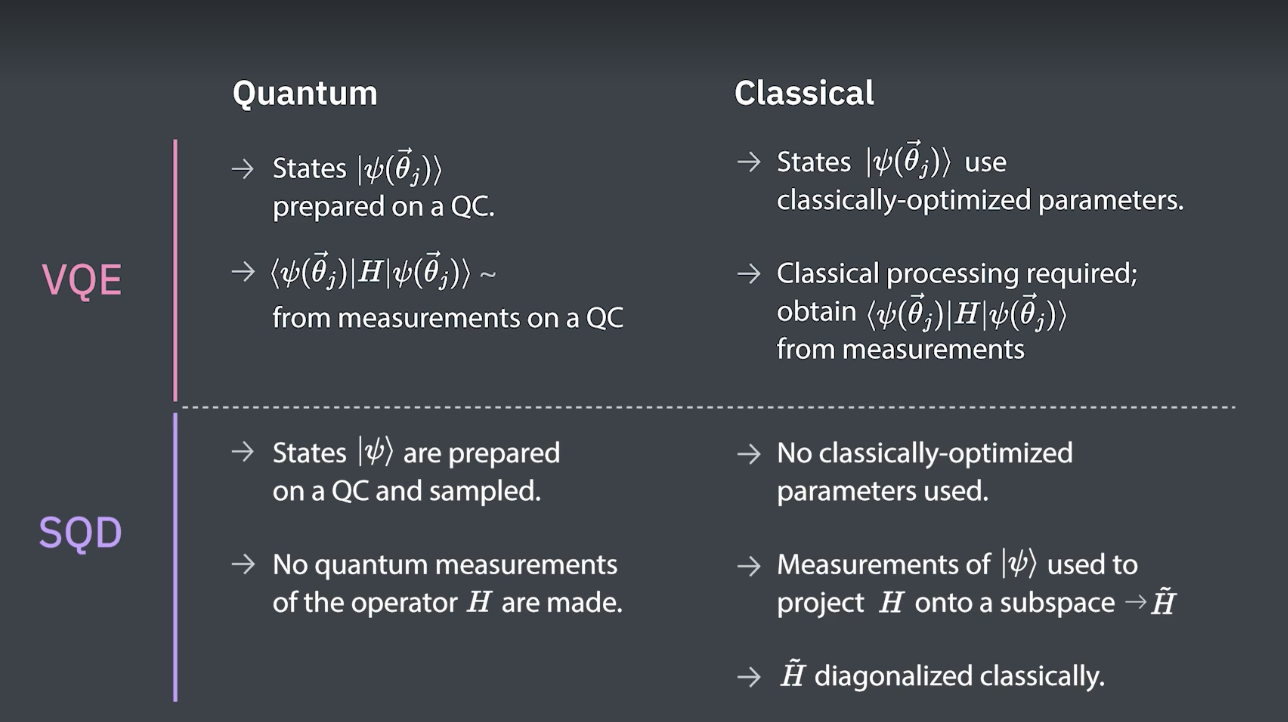

### Quantum chemistry

The Hamiltonian of a molecular system can be written as

$$
\hat{H} = \sum_{ \substack{pr\\\sigma} } h_{pr} \, \hat{a}^\dagger_{p\sigma} \hat{a}_{r\sigma}
+ \frac12
\sum_{ \substack{prqs\\\sigma\tau} }
h_{prqs} \,
\hat{a}^\dagger_{p\sigma}
\hat{a}^\dagger_{q\tau}
\hat{a}_{s\tau}
\hat{a}_{r\sigma},
$$

where the $h_{pr}$ and $h_{prqs}$ are complex numbers called molecular integrals that can be calculated from the specification of the molecule using a computer program. In this tutorial, we compute the integrals using the [PySCF](https://pyscf.org/) software package.

For details about how the molecular Hamiltonian is derived, consult a textbook on quantum chemistry (for example, *Modern Quantum Chemistry* by Szabo and Ostlund). For a high-level explanation of how quantum chemistry problems are mapped onto quantum computers, check out the lecture [*Mapping Problems to Qubits*](https://youtube.com/watch?v=TyFU6r8uEsE\&t=900) from Qiskit Global Summer School 2024.

### Local unitary cluster Jastrow (LUCJ) ansatz

SQD requires a quantum circuit ansatz to draw samples from. In this tutorial, we'll use the [local unitary cluster Jastrow (LUCJ)](https://pubs.rsc.org/en/content/articlelanding/2023/sc/d3sc02516k) ansatz due to its combination of physical motivation and hardware-friendliness. We'll use [ffsim](https://qiskit-community.github.io/ffsim/) to construct the ansatz circuit.

The LUCJ ansatz adapts to QPUs with restricted qubit connectivity. The spin orbitals are mapped to qubits such that the ansatz does not require routing with SWAP gates. IBM® hardware has a heavy-hex lattice qubit topology, in which case we can adopt a "zig-zag" pattern, depicted below. In this pattern, orbitals with the same spin are mapped to qubits with a line topology (red and blue circles), and a connection between orbitals of different spin is present at every 4th spatial orbital, with the connection being facilitated by an ancilla qubit (purple circles).

![Qubit mapping diagram for the LUCJ ansatz on a heavy-hex lattice](https://quantum.cloud.ibm.com/docs/images/tutorials/improving-energy-estimation-of-a-fermionic-hamiltonian-with-sqd/7e0ee7e1-2d24-417f-ac59-25c58db79aa9.avif)

### Self-consistent configuration recovery

The self-consistent configuration recovery procedure is designed to extract as much signal as possible from noisy quantum samples. Because the molecular Hamiltonian conserves particle number and spin Z, it makes sense to choose a circuit ansatz that also conserves these symmetries. When applied to the Hartree-Fock state, the resulting state has a fixed particle number and spin Z in the noiseless setting. Therefore, the spin-$\alpha$ and spin-$\beta$ halves of any bitstring sampled from this state should have the same [Hamming weight](https://en.wikipedia.org/wiki/Hamming_weight) as in the Hartree-Fock state. Due to the presence of noise in current quantum processors, some measured bitstrings will violate this property. A simple form of postselection would discard these bitstrings, but this is wasteful because those bitstrings might still contain some signal. The self-consistent recovery procedure attempts to recover some of that signal in post-processing. The procedure is iterative and requires as input an estimate of the average occupancies of each orbital in the ground state, which is first computed from the raw samples. The procedure is run in a loop, and each iteration has the following steps:

1. For each bitstring that violates the specified symmetries, flip its bits with a probabilistic procedure designed to bring the bitstring closer to the current estimate of the average orbital occupancies, to obtain a new bitstring.
2. Collect all of the old and new bitstrings that satisfy the symmetries, and subsample subsets of a fixed size, chosen in advance.
3. For each subset of bitstrings, project the Hamiltonian into the subspace spanned by the corresponding basis vectors (see the [previous section](#quantum-chemistry) for a description of these basis vectors), and compute a ground state estimate of the projected Hamiltonian on a classical computer.
4. Update the estimate of the average orbital occupancies with the ground state estimate with the lowest energy.

### SQD workflow diagram

The SQD workflow is depicted in the following diagram:

![Workflow diagram of the SQD algorithm](https://quantum.cloud.ibm.com/docs/images/tutorials/improving-energy-estimation-of-a-fermionic-hamiltonian-with-sqd/fd7e816f-4e2e-4dd7-a7da-f71afb9ca68d.avif)


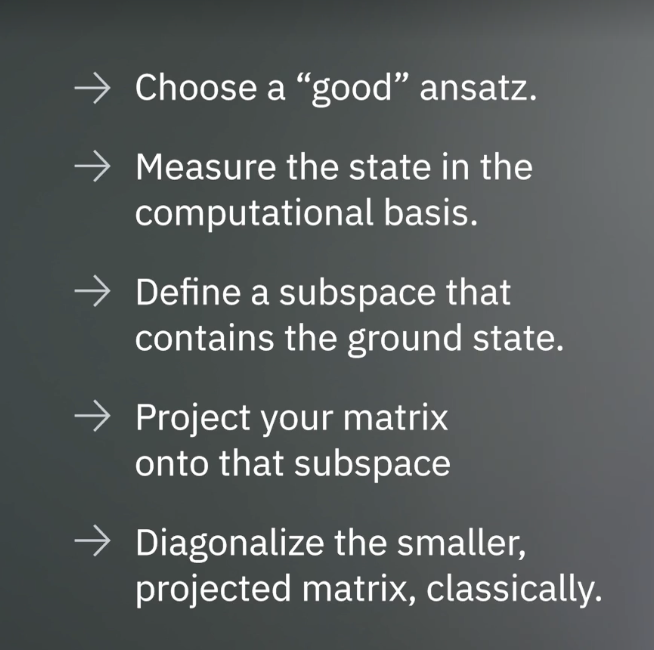



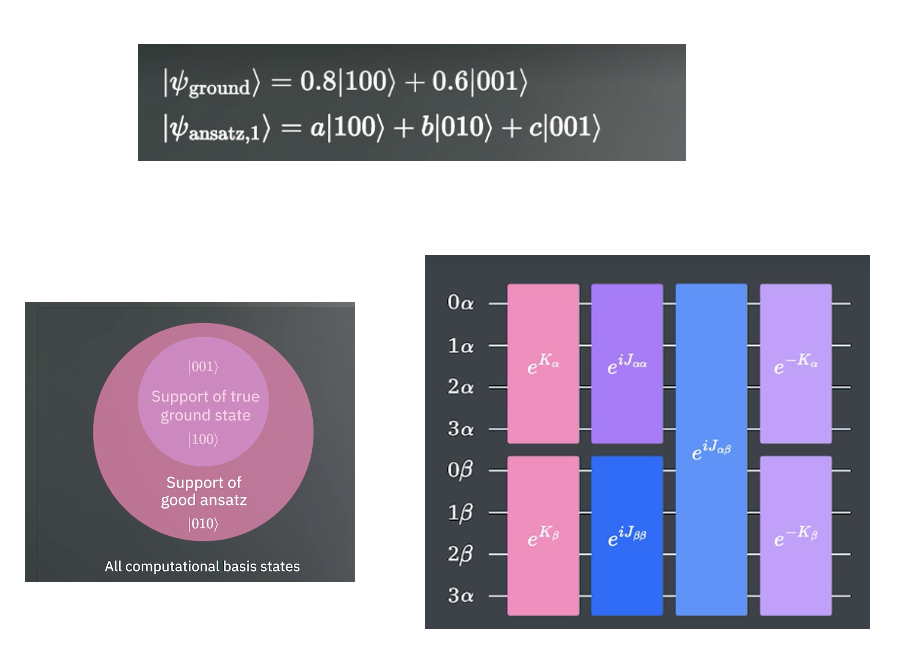


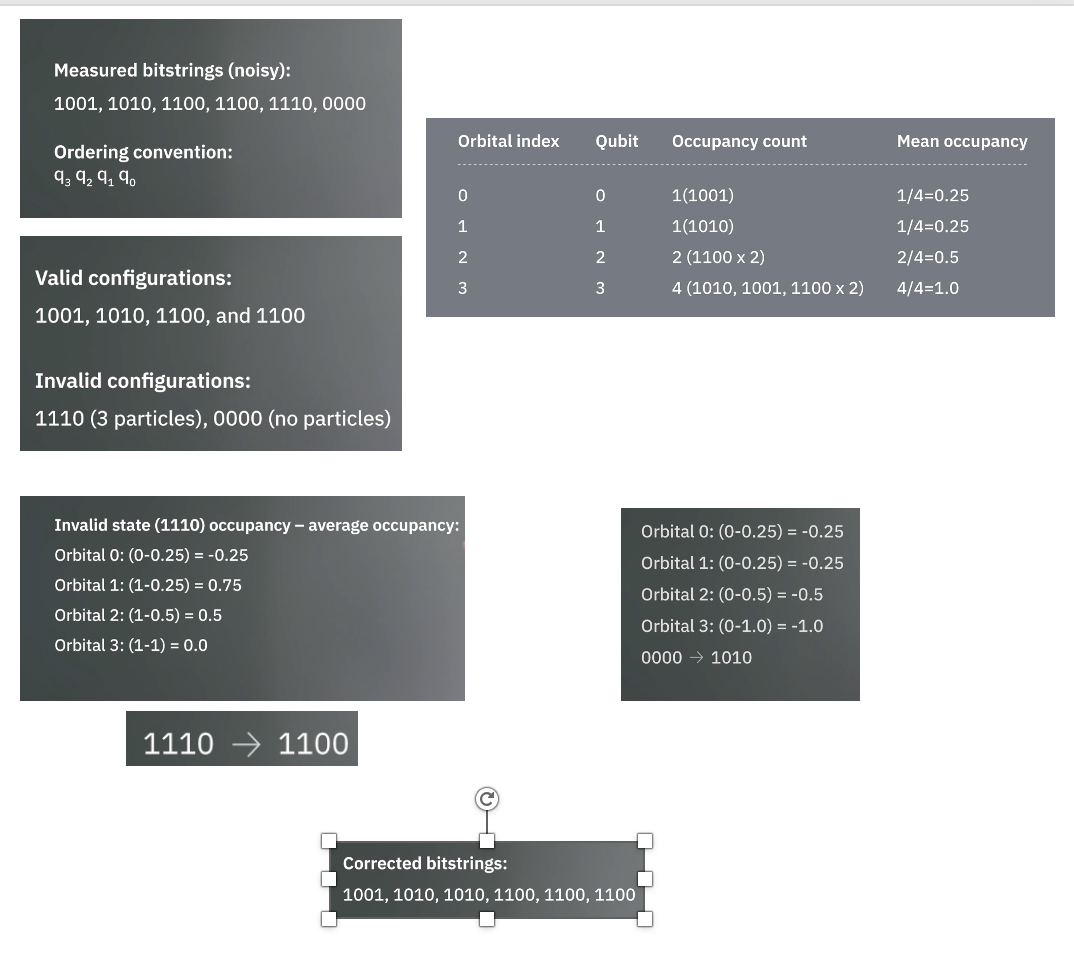

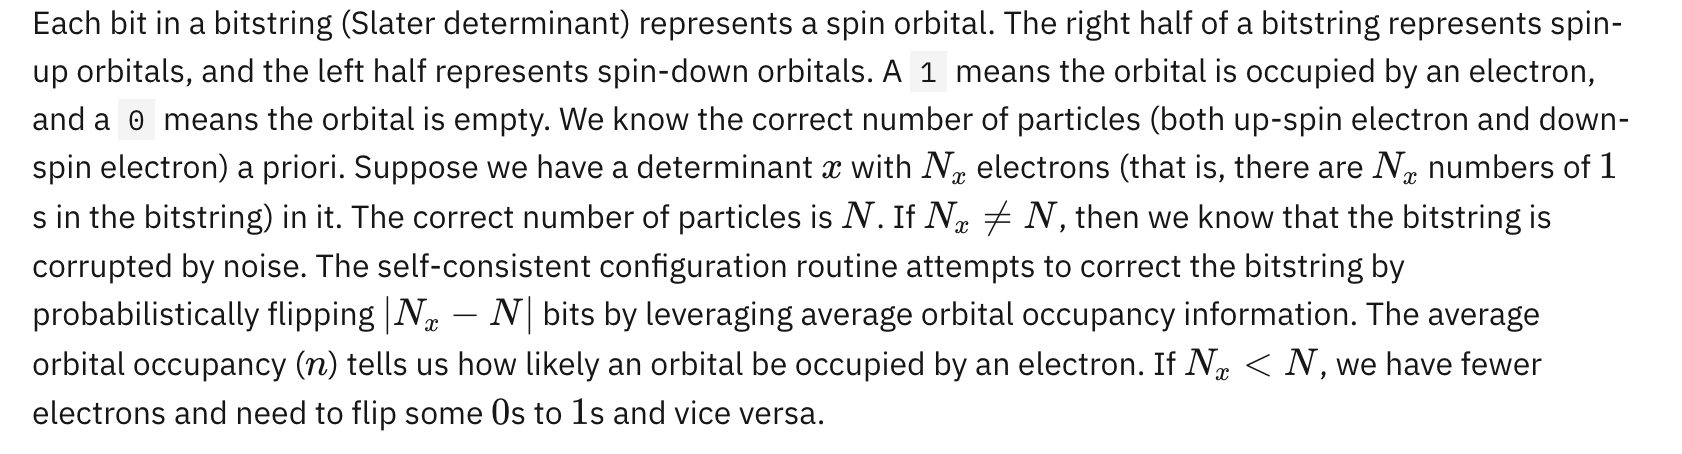

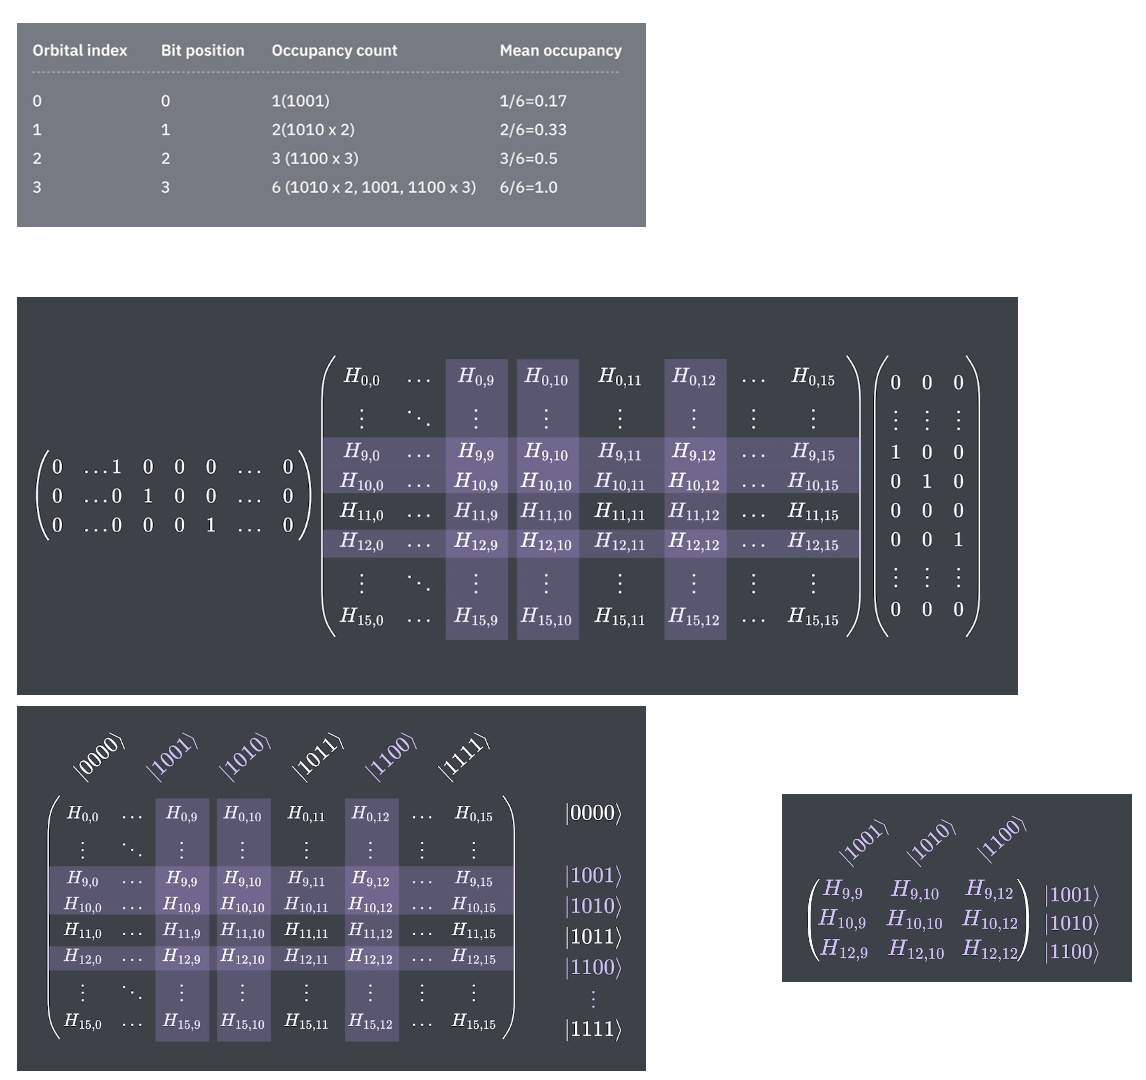

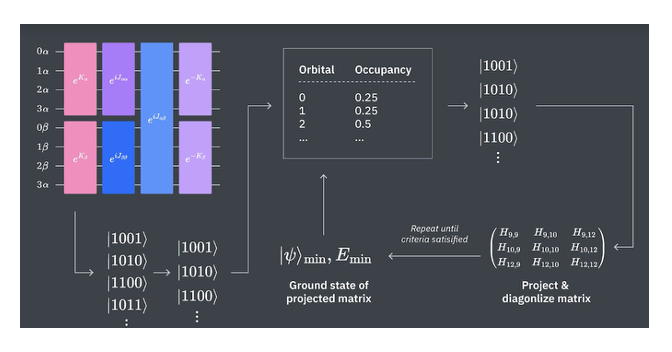

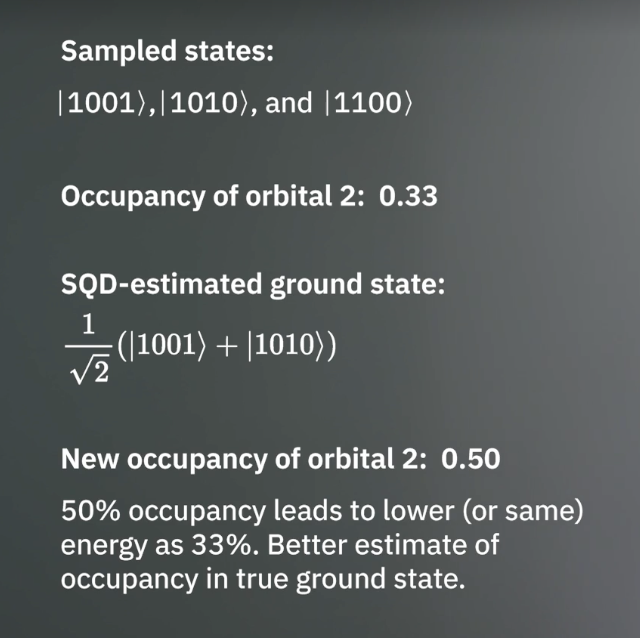

## Requirements

Before starting this tutorial, ensure that you have the following installed:

* Qiskit SDK v1.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)
* SQD Qiskit addon v0.11 or later (`pip install qiskit-addon-sqd`)
* ffsim v0.0.75 or later (`pip install ffsim`)




## Setup


In [1]:
import math

import ffsim
import matplotlib.pyplot as plt
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

## Small-scale simulator example

In this tutorial, we will find an approximation to the ground state of a nitrogen molecule near its equilibrium bond distance. We first use a small STO-6G basis set so that we can simulate the experiment and make sure it's working.



### Step 1: Map classical inputs to a quantum problem

First, we specify the molecule and its properties.



In [2]:
# Specify molecule properties
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=[["N", (0, 0, 0)], ["N", (1.0, 0, 0)]],
    basis="sto-6g",
    symmetry="Dooh",
)

# Define active space
n_frozen = 2
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

# Compute exact energy using FCI
reference_energy = cas.run().e_tot

print(f"norb = {norb}")
print(f"nelec = {nelec}")

converged SCF energy = -108.464957764796
CASCI E = -108.595987350986  E(CI) = -32.4115475088426  S^2 = 0.0000000
norb = 8
nelec = (5, 5)


/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/scf/addons.py:600: RuntimeWarning: divide by zero encountered in dot
  return lib.cho_solve(s22, numpy.dot(s21, mo1), strict_sym_pos=False)
/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/scf/addons.py:600: RuntimeWarning: overflow encountered in dot
  return lib.cho_solve(s22, numpy.dot(s21, mo1), strict_sym_pos=False)
/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/scf/addons.py:600: RuntimeWarning: invalid value encountered in dot
  return lib.cho_solve(s22, numpy.dot(s21, mo1), strict_sym_pos=False)
/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/scf/hf.py:852: RuntimeWarning: divide by zero encountered in dot
  dm = (mocc*mo_occ[mo_occ>0]).dot(mocc.conj().T)
/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/scf/hf.py:852: RuntimeWarning: o

Before constructing the LUCJ ansatz circuit, we first perform a CCSD calculation in the following code cell. The [$t_1$ and $t_2$ amplitudes](https://en.wikipedia.org/wiki/Coupled_cluster#Cluster_operator) from this calculation will be used to initialize the parameters of the ansatz.


Coupled cluster (CC) is a numerical technique used for describing many-body systems. Its most common use is as one of several post-Hartree–Fock ab initio quantum chemistry methods in the field of computational chemistry, but it is also used in nuclear physics.

In [3]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

E(CCSD) = -108.5933309085007  E_corr = -0.1283731437052347


/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/cc/ccsd.py:1414: RuntimeWarning: divide by zero encountered in dot
  self.fock = reduce(numpy.dot, (mo_coeff.conj().T, fockao, mo_coeff))
/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/cc/ccsd.py:1414: RuntimeWarning: overflow encountered in dot
  self.fock = reduce(numpy.dot, (mo_coeff.conj().T, fockao, mo_coeff))
/Users/debasmitabhoumik/miniforge3/envs/workshop_env/lib/python3.12/site-packages/pyscf/cc/ccsd.py:1414: RuntimeWarning: invalid value encountered in dot
  self.fock = reduce(numpy.dot, (mo_coeff.conj().T, fockao, mo_coeff))


Now, we use [ffsim](https://github.com/qiskit-community/ffsim) to create the ansatz circuit. Since our molecule has a closed-shell Hartree-Fock state, we use the spin-balanced variant of the UCJ ansatz, [UCJOpSpinBalanced](https://qiskit-community.github.io/ffsim/api/ffsim.html#ffsim.UCJOpSpinBalanced). We set `optimize=True` in the `from_t_amplitudes` method to enable the "compressed" double-factorization of the $t_2$ amplitudes (see [The local unitary cluster Jastrow (LUCJ) ansatz](https://qiskit-community.github.io/ffsim/explanations/lucj.html#Parameter-initialization-from-CCSD) at ffsim's documentation for details).

Because the LUCJ ansatz adapts to the available connectivity of the QPU, we have to initialize the QPU backend before creating the ansatz. For now, we'll create a generic backend with a heavy-hex coupling map and a gate set that the LUCJ ansatz naturally decomposes to. Then, we'll use `ffsim.qiskit.generate_lucj_pass_manager` to create a pass manager that is specialized for transpiling the LUCJ ansatz to the given backend according to the "zig-zag" layout described in the [background section on the LUCJ ansatz](#local-unitary-cluster-jastrow-lucj-ansatz). This function uses a scoring heuristic to minimize the errors associated with the selected layout, which is important if your backend is a real QPU, or a simulator with a noise model. In addition to returning the pass manager, this function also returns the alpha-beta coupling pairs that can be implemented on the hardware. If not all pairs can be implemented, it emits a warning.



In [4]:
import warnings

from qiskit.transpiler import CouplingMap

warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

# Set ansatz properties
n_reps = 1
pairs_aa = [(p, p + 1) for p in range(norb - 1)]

# Let generate_lucj_pass_manager determine the alpha-beta interactions
pairs_ab = None

# Initialize backend
coupling_map = CouplingMap.from_heavy_hex(3)
backend = GenericBackendV2(
    coupling_map.size(),
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

# Create pass manager
pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
    backend=backend,
    norb=norb,
    connectivity="heavy-hex",
    interaction_pairs=(pairs_aa, pairs_ab),
    optimization_level=3,
)

# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell
    # from running too long. Removing this line may improve results.
    options=dict(maxiter=1000),
)

# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it
# to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

Removing interaction (4, 4) from the end.


### Step 2: Optimize for quantum hardware execution

Next, we optimize the circuit for a target hardware. Typically, this step involves initializing the hardware backend and a pass manager for that backend. However, since the LUCJ ansatz is adapted to the hardware connectivity, we already performed these actions in the previous step. All that is left to do is run the pass manager on the circuit to transpile it to an ISA circuit that can be directly executed on the QPU.



In [5]:

isa_circuit = pass_manager.run(circuit)
print(f"Gate counts: {isa_circuit.count_ops()}")

Gate counts: OrderedDict({'xx_plus_yy': 86, 'p': 16, 'measure': 16, 'cp': 13, 'x': 10, 'swap': 2, 'barrier': 1})


### Step 3: Execute using Qiskit primitives

After optimizing the circuit for hardware execution, we are ready to run it on the target hardware and collect samples for ground state energy estimation. As we only have one circuit, we will use Qiskit Runtime's [Job execution mode](/docs/guides/execution-modes) and execute our circuit.



In [6]:
rng = np.random.default_rng()
sampler = StatevectorSampler(seed=rng)
job = sampler.run([isa_circuit], shots=100_000)

In [7]:
primitive_result = job.result()
pub_result = primitive_result[0]

### Step 4: Post-process and return result in desired classical format

A useful metric to judge the quality of the QPU output is the number of valid configurations returned. A valid configuration has the correct particle number and spin Z, which means that the right half of the bitstring has Hamming weight equal to the number of spin-up electrons, and the left half has Hamming weight equal to the number of spin-down electrons. The following cell computes the fraction of sampled configurations that are valid.



In [8]:
def is_valid_bitstring(
    bitstring: str, norb: int, nelec: tuple[int, int]
) -> bool:
    n_alpha, n_beta = nelec
    return (
        len(bitstring) == 2 * norb
        and bitstring[norb:].count("1") == n_alpha
        and bitstring[:norb].count("1") == n_beta
    )


bit_array = pub_result.data.meas
num_valid = sum(
    is_valid_bitstring(b, norb, nelec) for b in bit_array.get_bitstrings()
)
valid_fraction = num_valid / bit_array.num_shots
print(f"Fraction of sampled configurations that are valid: {valid_fraction}")

Fraction of sampled configurations that are valid: 1.0


All of the bitstrings are valid because we are sampling the circuit on a noiseless simulator. When running on a noisy QPU, the fraction will be less than one, but hopefully it will be larger than the fraction you would expect if the bitstrings were sampled uniformly at random, which is computed in the following cell.



In [9]:
expected_fraction_random = (
    math.comb(norb, n_alpha) * math.comb(norb, n_beta) / 2 ** (2 * norb)
)
print(
    f"Expected fraction of valid configurations from uniformly random bitstrings: "
    f"{expected_fraction_random}"
)

Expected fraction of valid configurations from uniformly random bitstrings: 0.0478515625


Now, we estimate the ground state energy of the Hamiltonian using the `diagonalize_fermionic_hamiltonian` function. This function performs the self-consistent configuration recovery procedure to iteratively refine the noisy quantum samples to improve the energy estimate. We pass a callback function so that we can save the intermediate results for later analysis. See the [API documentation](/docs/api/qiskit-addon-sqd/fermion#diagonalize_fermionic_hamiltonian) for explanations of the arguments to `diagonalize_fermionic_hamiltonian`.

Here, we use the `initial_occupancies` argument to `diagonalize_fermionic_hamiltonian` to specify the Hartree-Fock configuration as the initial guess for the orbital occupancies in the ground state. This approach is sensible for systems where the ground state has significant support on the Hartree-Fock configuration, but it might not be appropriate in other situations, though more advanced computational methods might yield better initial guesses in those cases. Specifying `initial_occupancies` also allows configuration recovery to run even if no valid configurations were sampled, as may be the case when sampling a large circuit on a noisy QPU. Without this argument, the configuration recovery would fail and raise an error if no valid configurations were provided.



In [10]:
from functools import partial

from qiskit_addon_sqd.fermion import (
    SCIResult,
    diagonalize_fermionic_hamiltonian,
    solve_sci_batch,
)

# SQD options
energy_tol = 1e-3
occupancies_tol = 1e-3
max_iterations = 5

# Eigenstate solver options
num_batches = 3
samples_per_batch = 300
symmetrize_spin = True
carryover_threshold = 1e-4
max_cycle = 200

# Use the Hartree-Fock configuration as an initial guess for the orbital occupancies
initial_occupancies = (
    np.array([1] * n_alpha + [0] * (norb - n_alpha)),
    np.array([1] * n_beta + [0] * (norb - n_beta)),
)

# Pass options to the built-in eigensolver. If you just want to use the defaults,
# you can omit this step, in which case you would not specify the sci_solver argument
# in the call to diagonalize_fermionic_hamiltonian below.
sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)

# List to capture intermediate results
result_history = []


def callback(results: list[SCIResult]):
    result_history.append(results)
    iteration = len(result_history)
    print(f"Iteration {iteration}")
    for i, result in enumerate(results):
        print(f"\tSubsample {i}")
        print(f"\t\tEnergy: {result.energy + nuclear_repulsion_energy}")
        print(
            f"\t\tSubspace dimension: {np.prod(result.sci_state.amplitudes.shape)}"
        )


result = diagonalize_fermionic_hamiltonian(
    hcore,
    eri,
    bit_array,
    samples_per_batch=samples_per_batch,
    norb=norb,
    nelec=nelec,
    num_batches=num_batches,
    energy_tol=energy_tol,
    occupancies_tol=occupancies_tol,
    max_iterations=max_iterations,
    sci_solver=sci_solver,
    symmetrize_spin=symmetrize_spin,
    initial_occupancies=initial_occupancies,
    carryover_threshold=carryover_threshold,
    callback=callback,
    seed=rng,
)

final_energy = result.energy + nuclear_repulsion_energy
energy_error = final_energy - reference_energy
print(f"Final energy: {final_energy}")
print(f"Final energy error: {energy_error}")

Iteration 1
	Subsample 0
		Energy: -108.58066301711656
		Subspace dimension: 256
	Subsample 1
		Energy: -108.58066301711656
		Subspace dimension: 256
	Subsample 2
		Energy: -108.58066301711656
		Subspace dimension: 256
Iteration 2
	Subsample 0
		Energy: -108.58066301711656
		Subspace dimension: 256
	Subsample 1
		Energy: -108.58066301711656
		Subspace dimension: 256
	Subsample 2
		Energy: -108.58066301711656
		Subspace dimension: 256
Final energy: -108.58066301711656
Final energy error: 0.015324333869472184


#### Visualize the results

The first plot shows that in this simulation we are already within `1 mH` of the exact answer after the first iteration (chemical accuracy is typically accepted to be `1 kcal/mol` $\approx$ `1.6 mH`). This is a small system, though, and because the samples are noiseless, configuration recovery is not needed. On a larger system run on a noisy QPU, multiple configuration recovery iterations might be needed, and the final accuracy might be worse. Generally, the energy can be improved by allowing more configuration recovery iterations or by increasing the number of samples per batch.

The second plot shows the average occupancy of each spatial orbital after the final iteration. We can see that both the spin-up and spin-down electrons occupy the first five orbitals with high probability in our solutions.



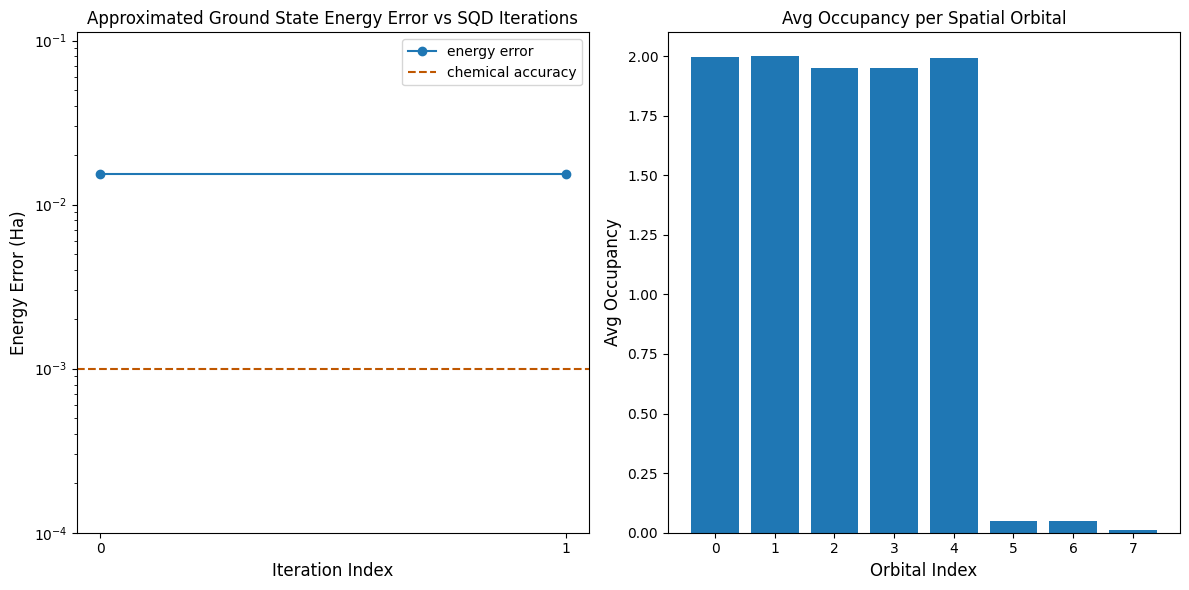

In [11]:
# Data for energies plot
x1 = range(len(result_history))
min_e = [
    min(result, key=lambda res: res.energy).energy + nuclear_repulsion_energy
    for result in result_history
]
e_diff = [abs(e - reference_energy) for e in min_e]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = np.sum(result.orbital_occupancies, axis=0)
x2 = range(len(y2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(
    y=chem_accuracy,
    color="#BF5700",
    linestyle="--",
    label="chemical accuracy",
)
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

plt.tight_layout()
plt.show()

## Large-scale hardware example

Now, we run a larger example on real quantum hardware. Here, we'll derive an active space for the nitrogen molecule from the cc-pVDZ basis set.



### Steps 1-4

Here we put all the steps together into a single workflow at a larger scale, which is then run on real quantum hardware.



In [13]:

# ------------------------------ Step 1 ------------------------------
# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=[["N", (0, 0, 0)], ["N", (1.0, 0, 0)]],
    basis="cc-pvdz",
    symmetry="Dooh",
)

# Define active space
n_frozen = 2
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

# Store reference energy from SCI calculation performed separately
reference_energy = -109.22802921665716

print(f"norb = {norb}")
print(f"nelec = {nelec}")

# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

# Set ansatz properties
n_reps = 1
pairs_aa = [(p, p + 1) for p in range(norb - 1)]

# Let generate_lucj_pass_manager determine the alpha-beta interactions
pairs_ab = None

# Initialize backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=133
)
print(f"Using backend {backend.name}")

# Create pass manager
pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
    backend=backend,
    norb=norb,
    connectivity="heavy-hex",
    interaction_pairs=(pairs_aa, pairs_ab),
    optimization_level=3,
)

# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell
    # from running too long. Removing this line may improve results.
    options=dict(maxiter=1000),
)

# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it
# to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()



converged SCF energy = -108.929838385609
norb = 26
nelec = (5, 5)
E(CCSD) = -109.2177884185543  E_corr = -0.2879500329450038
Using backend ibm_pittsburgh


### If you dont find alpha beta in one go run again


In [14]:
qubits

QuantumRegister(52, 'q')

In [15]:
# ------------------------------ Step 2 ------------------------------

isa_circuit = pass_manager.run(circuit)
print(f"Gate counts: {isa_circuit.count_ops()}")

Gate counts: OrderedDict({'sx': 7023, 'rz': 6979, 'cz': 1850, 'x': 65, 'measure': 52, 'barrier': 1})


In [16]:
# ------------------------------ Step 3 ------------------------------
sampler = Sampler(mode=backend)
sampler.options.environment.job_tags = ["TUT_SQD"]
job = sampler.run([isa_circuit], shots=100_000)
primitive_result = job.result()
pub_result = primitive_result[0]


Fraction of sampled configurations that are valid: 0.00138
Expected fraction of valid configurations from uniformly random bitstrings: 9.607888706852918e-07


Iteration 1
	Subsample 0
		Energy: -109.11606075812867
		Subspace dimension: 151321
	Subsample 1
		Energy: -109.1091421876598
		Subspace dimension: 152100
	Subsample 2
		Energy: -109.09496796980085
		Subspace dimension: 136900
Iteration 2
	Subsample 0
		Energy: -109.14580255398025
		Subspace dimension: 270400
	Subsample 1
		Energy: -109.16086894410839
		Subspace dimension: 261121
	Subsample 2
		Energy: -109.16525861521131
		Subspace dimension: 257049
Iteration 3
	Subsample 0
		Energy: -109.17071518891758
		Subspace dimension: 357604
	Subsample 1
		Energy: -109.17525506606492
		Subspace dimension: 373321
	Subsample 2
		Energy: -109.1698510174356
		Subspace dimension: 366025
Iteration 4
	Subsample 0
		Energy: -109.17875634647545
		Subspace dimension: 514089
	Subsample 1
		Energy: -109.17734629786942
		Subspace dimension: 527076
	Subsample 2
		Energy: -109.17763515589581
		Subspace dimension: 537289
Iteration 5
	Subsample 0
		Energy: -109.18774849673706
		Subspace dimension: 652864
	Subsa

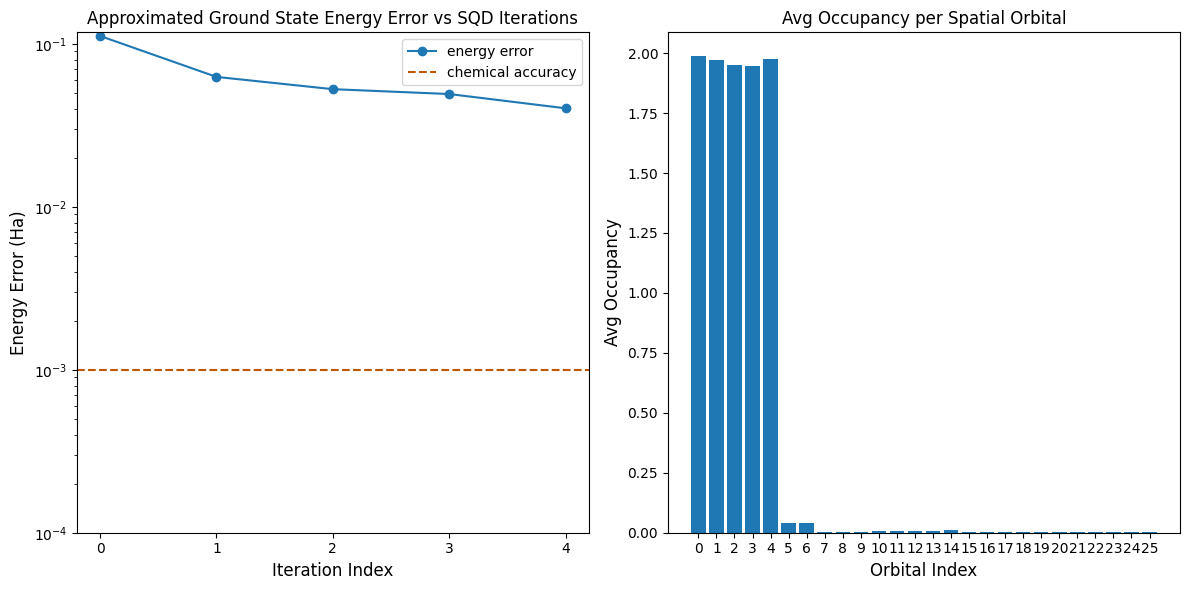

In [17]:
# ------------------------------ Step 4 ------------------------------

bit_array = pub_result.data.meas
num_valid = sum(
    is_valid_bitstring(b, norb, nelec) for b in bit_array.get_bitstrings()
)
valid_fraction = num_valid / bit_array.num_shots
print(f"Fraction of sampled configurations that are valid: {valid_fraction}")
expected_fraction_random = (
    math.comb(norb, n_alpha) * math.comb(norb, n_beta) / 2 ** (2 * norb)
)
print(
    f"Expected fraction of valid configurations from uniformly random bitstrings: "
    f"{expected_fraction_random}"
)
# SQD options
energy_tol = 1e-3
occupancies_tol = 1e-3
max_iterations = 5

# Eigenstate solver options
num_batches = 3
samples_per_batch = 300
symmetrize_spin = True
carryover_threshold = 1e-4
max_cycle = 200

# Use the Hartree-Fock configuration as an initial guess for the
# orbital occupancies
initial_occupancies = (
    np.array([1] * n_alpha + [0] * (norb - n_alpha)),
    np.array([1] * n_beta + [0] * (norb - n_beta)),
)

# Pass options to the built-in eigensolver. If you just want to use the defaults,
# you can omit this step, in which case you would not specify the
# sci_solver argument in the call to diagonalize_fermionic_hamiltonian below.
sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)

# List to capture intermediate results
result_history = []


result = diagonalize_fermionic_hamiltonian(
    hcore,
    eri,
    bit_array,
    samples_per_batch=samples_per_batch,
    norb=norb,
    nelec=nelec,
    num_batches=num_batches,
    energy_tol=energy_tol,
    occupancies_tol=occupancies_tol,
    max_iterations=max_iterations,
    sci_solver=sci_solver,
    symmetrize_spin=symmetrize_spin,
    initial_occupancies=initial_occupancies,
    carryover_threshold=carryover_threshold,
    callback=callback,
    seed=rng,
)

final_energy = result.energy + nuclear_repulsion_energy
energy_error = final_energy - reference_energy
print(f"Final energy: {final_energy}")
print(f"Final energy error: {energy_error}")

# Data for energies plot
x1 = range(len(result_history))
min_e = [
    min(result, key=lambda res: res.energy).energy + nuclear_repulsion_energy
    for result in result_history
]
e_diff = [abs(e - reference_energy) for e in min_e]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = np.sum(result.orbital_occupancies, axis=0)
x2 = range(len(y2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(
    y=chem_accuracy,
    color="#BF5700",
    linestyle="--",
    label="chemical accuracy",
)
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

plt.tight_layout()
plt.show()

- SQD needs LUCJ circuit + good CCSD initialization
- If CCSD fails or gives wrong ansatz → bad ground state
- "Solutions: (1) Try SKQD (no ansatz needed), (2) Use SqDRIFT (randomization helps)"

# Issue with SQD ? You need to find a good ansatz beforehand. Solution SKQD

## SKQD (Sample-based Krylov Quantum Diagonalization)

Sample-based Krylov Quantum Diagonalization (SKQD) is another powerful quantum sample-based algorithm that builds upon the principles of SQD. While its goal is the same—to find a good subspace for diagonalization—SKQD employs a more structured method for generating the bitstrings, especially for problems like lattice Hamiltonians.

The core idea of SKQD is that instead of optimizing a parameterized circuit to find a good ansatz, one can provably converge to the ground state by sampling from a set of states generated by the system's own natural time evolution - the Krylov subspace.

https://quantum.cloud.ibm.com/learning/en/courses/integrating-quantum-and-high-performance-computing/sqd-skqd

and

https://quantum.cloud.ibm.com/docs/en/tutorials/sample-based-krylov-quantum-diagonalization

# SQDRIFT

It merges the mathematical rigor of SKQD (Sample-based Krylov Quantum Diagonalization) with the randomized compilation of qDRIFT.

Instead of simulating every single electron interaction sequentially (which creates impossible, million-gate circuits), it weights interactions by their physical strength and randomly samples only a tiny handful to simulate.




# SUMMARY

## Krylov Quantum Diagonalization (KQD): 
Projects the full Hamiltonian onto a basis generated by repeatedly applying the time-evolution operator to a reference state. It evaluates the overlap matrix and projected Hamiltonian directly on the quantum computer using complex subroutines. The necessity for deep, deterministic Trotter circuits makes it highly susceptible to decoherence on near-term devices.

## Sample-based Quantum Diagonalization (SQD): 
Bypasses time-evolution entirely by preparing a trial state and measuring it in the computational basis to find dominant configurations. These sampled configurations form the subspace for classical diagonalization. While extremely hardware-friendly, the number of required samples scales exponentially if the ground state is highly delocalized across the Hilbert space.

## Sample-based Krylov Quantum Diagonalization (SKQD):
 A hybrid approach that generates a Krylov subspace but evaluates the necessary matrix elements using randomized sampling techniques rather than coherent quantum subroutines like the Hadamard test. This bridges the convergence guarantees of KQD with the measurement efficiency of SQD.

## SqDRIFT: 
The most hardware-optimized variant, merging SKQD with the qDRIFT protocol. Instead of simulating the full Hamiltonian deterministically, SqDRIFT randomly samples individual Hamiltonian terms according to their interaction strengths. This stochastic compilation provably reduces circuit depth and gate counts, making it highly viable for executing chemistry simulations on near-term hardware.